In [2]:
# Activating Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [3]:
# Loading the data
import pandas as pd
gc = pd.read_csv("../data/growth_data.csv")


In [4]:
gc.head()

,Time,OD
0,0,0.050
1,1,0.051
2,2,0.052
3,3,0.053
4,4,0.055


In [5]:
gc.tail()

,Time,OD
95,95,2.18
96,96,2.16
97,97,2.14
98,98,2.12
99,99,2.10


In [6]:
# Cleaning the data

gc.columns = gc.columns.str.strip()


In [7]:
print(gc.columns)

Index(['Time', 'OD'], dtype='object')


In [8]:
# Finding Growth Rate
gc['growth_rate'] = gc['OD'].diff()
print(gc)

    Time     OD  growth_rate
0      0  0.050          NaN
1      1  0.051        0.001
2      2  0.052        0.001
3      3  0.053        0.001
4      4  0.055        0.002
..   ...    ...          ...
95    95  2.180       -0.020
96    96  2.160       -0.020
97    97  2.140       -0.020
98    98  2.120       -0.020
99    99  2.100       -0.020

[100 rows x 3 columns]


In [9]:
# Smoothen growth rate (It is important step)
gc['growth_rate_smooth'] = gc['growth_rate'].rolling(5).mean()
print(gc)

    Time     OD  growth_rate  growth_rate_smooth
0      0  0.050          NaN                 NaN
1      1  0.051        0.001                 NaN
2      2  0.052        0.001                 NaN
3      3  0.053        0.001                 NaN
4      4  0.055        0.002                 NaN
..   ...    ...          ...                 ...
95    95  2.180       -0.020              -0.012
96    96  2.160       -0.020              -0.016
97    97  2.140       -0.020              -0.020
98    98  2.120       -0.020              -0.024
99    99  2.100       -0.020              -0.020

[100 rows x 4 columns]


In [10]:
# Detecting the Bacterial Growth Phases

def identify_phase(row):
    rate = row['growth_rate_smooth']
    
    if pd.isna(rate):
        return "Lag"
    
    elif rate < 0.005:
        return "Stationary"
    
    elif rate > gc['growth_rate_smooth'].max() * 0.7:
        return "Exponential Peak"
    
    elif rate > 0:
        return "Log Phase"
    
    else:
        return "Death Phase"
    
gc['phase'] = gc.apply(identify_phase, axis=1)

print(gc)


    Time     OD  growth_rate  growth_rate_smooth       phase
0      0  0.050          NaN                 NaN         Lag
1      1  0.051        0.001                 NaN         Lag
2      2  0.052        0.001                 NaN         Lag
3      3  0.053        0.001                 NaN         Lag
4      4  0.055        0.002                 NaN         Lag
..   ...    ...          ...                 ...         ...
95    95  2.180       -0.020              -0.012  Stationary
96    96  2.160       -0.020              -0.016  Stationary
97    97  2.140       -0.020              -0.020  Stationary
98    98  2.120       -0.020              -0.024  Stationary
99    99  2.100       -0.020              -0.020  Stationary

[100 rows x 5 columns]


In [11]:
# Finding Maximum Growth
max_growth = gc.loc[gc['growth_rate_smooth'].idxmax()]

print("Max growth at time:", max_growth['Time'])


Max growth at time: 24


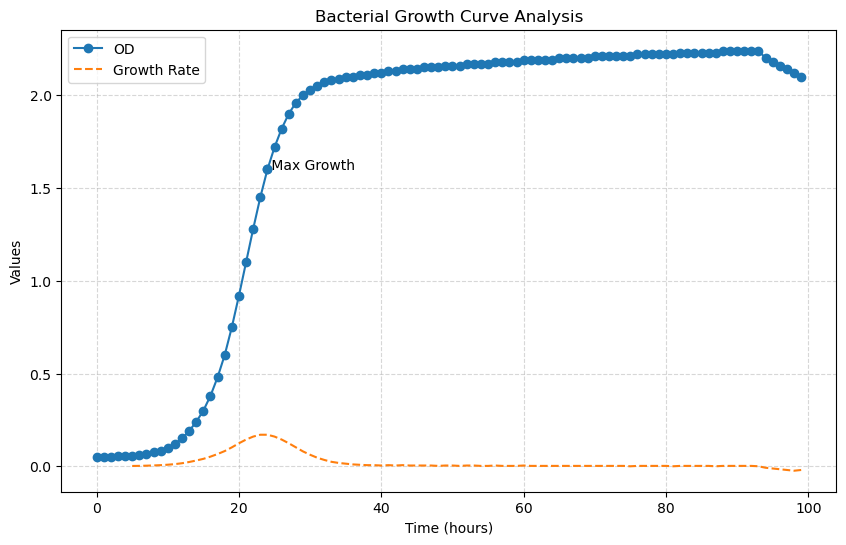

In [15]:
# Plotting to Visualize the Curve
plt.figure(figsize=(10,6))

# OD curve
plt.plot(gc['Time'], gc['OD'], marker='o', label='OD')

# Growth rate (smoothed)
plt.plot(gc['Time'], gc['growth_rate_smooth'], linestyle='--', label='Growth Rate')

# Highlighting max growth
plt.scatter(max_growth['Time'], max_growth['OD'])
plt.text(max_growth['Time'], max_growth['OD'], " Max Growth")

plt.xlabel("Time (hours)")
plt.ylabel("Values")
plt.title("Bacterial Growth Curve Analysis")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Saving the plot
plt.savefig("../images/growth_curve.png", dpi=300)

plt.show()

